# Learning to Grasp a Cube with SAC

This notebook trains a Soft Actor-Critic (SAC) policy to grasp a single cube
from a tabletop scene.  No symbolic planning — pure RL from a dense reward.

**Observation:** joint positions, EE pose, object pose, RGB from a fixed workspace camera  
**Action:** Cartesian EE delta (3 pos + 3 rot) + gripper  
**Reward:** `dense_grasp` — negative EE-to-object distance + lift bonus  
**Done:** object lifted > 5 cm above initial height

Prerequisites: `pip install stable-baselines3`

## 1 — Build the scene

In [8]:
from tampanda.scenes import ArmSceneBuilder, BLOCK_MEDIUM_TEMPLATE, TABLE_TEMPLATE


def make_scene() -> ArmSceneBuilder:
    b = ArmSceneBuilder()
    b.add_resource("table", TABLE_TEMPLATE)
    b.add_resource("cube",  BLOCK_MEDIUM_TEMPLATE)

    b.add_object("table", pos=[0.45, 0.0, 0.0])
    # Cube rests on table surface (table top ≈ 0.27 m, block half-height ≈ 0.04 m)
    b.add_object("cube", name="cube_0", pos=[0.45, 0.0, 0.315])

    # Fixed workspace camera — angled down from the front-right
    b.add_camera_orbit(
        "workspace",
        target=[0.45, 0.0, 0.35],
        distance=0.75,
        elevation=45,
        azimuth=45,
        fovy=60,
    )
    return b


scene = make_scene()
print("Scene built.")

Scene built.


## 2 — Create the Gym environment

In [9]:
from tampanda.gym import TampandaGymEnv

env = TampandaGymEnv(
    scene=make_scene(),
    obs=["joints", "ee_pose", "object_poses", "rgb"],
    action_space_type="cartesian_delta",
    include_gripper=True,
    reward_fn="dense_grasp",
    cameras=["workspace"],
    image_size=(64, 64),
    object_names=["cube_0"],
    max_episode_steps=300,
    n_substeps=5,
    render_mode="rgb_array",
)

print("Observation space:", env.observation_space)
print("Action space:     ", env.action_space)

Observation space: Dict('ee_pose': Box(-inf, inf, (7,), float32), 'joints': Box(-3.1415927, 3.1415927, (7,), float32), 'object_poses': Box(-inf, inf, (7,), float32), 'rgb': Box(0, 255, (64, 64, 3), uint8))
Action space:      Box(-1.0, 1.0, (7,), float32)


## 3 — Inspect the reward signal on a hand-coded approach

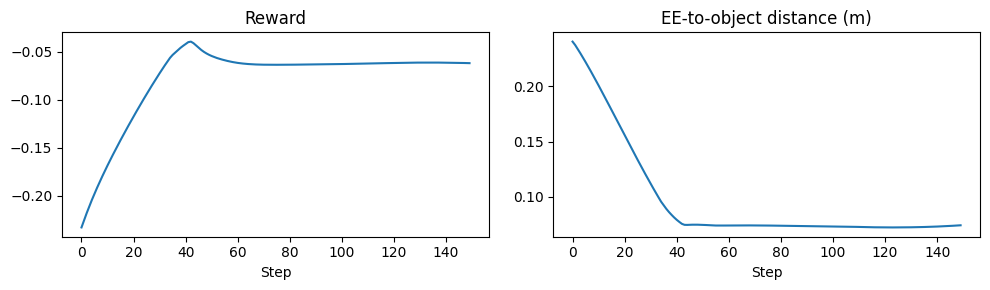

In [10]:
import numpy as np
import matplotlib.pyplot as plt

obs, info = env.reset(seed=42)

rewards = []
ee_dists = []

# Scripted: move towards cube, then close gripper
for step in range(150):
    ee_pos  = env.get_ee_pos()
    obj_pos = env.sim.get_object_position("cube_0")
    delta   = (obj_pos - ee_pos)
    dist    = np.linalg.norm(delta)

    pos_act = np.clip(delta / max(dist, 0.01), -1, 1) * 0.5
    gripper = np.array([-1.0] if dist < 0.05 else [1.0])  # close when near
    action  = np.concatenate([pos_act, [0, 0, 0], gripper]).astype(np.float32)

    obs, r, terminated, truncated, info = env.step(action)
    rewards.append(r)
    ee_dists.append(dist)
    if terminated:
        print(f"  Grasped at step {step}!")
        break

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(rewards);  axes[0].set_title("Reward")
axes[1].plot(ee_dists); axes[1].set_title("EE-to-object distance (m)")
for ax in axes:
    ax.set_xlabel("Step")
plt.tight_layout()
plt.show()

## 4 — Render a reset frame

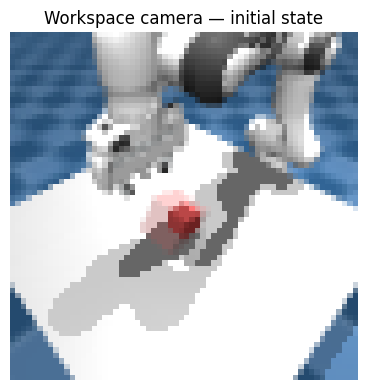

In [11]:
obs, _ = env.reset(seed=0)
frame  = env.render()

plt.figure(figsize=(4, 4))
plt.imshow(frame)
plt.axis("off")
plt.title("Workspace camera — initial state")
plt.tight_layout()
plt.show()

## 5 — Train with SAC

> **Note:** SAC trains on CPU here.  For serious runs use `device="cuda"` or
> `make_vec_env` with 8 parallel envs.
> A meaningful policy typically emerges around 50k–150k steps.

In [12]:
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import EvalCallback

train_env = TampandaGymEnv(
    scene=make_scene(),
    obs=["joints", "ee_pose", "object_poses"],   # no RGB during training for speed
    action_space_type="cartesian_delta",
    include_gripper=True,
    reward_fn="dense_grasp",
    cameras=["workspace"],
    object_names=["cube_0"],
    max_episode_steps=300,
    n_substeps=5,
)

eval_env = TampandaGymEnv(
    scene=make_scene(),
    obs=["joints", "ee_pose", "object_poses"],
    action_space_type="cartesian_delta",
    include_gripper=True,
    reward_fn="sparse_grasp",
    cameras=["workspace"],
    object_names=["cube_0"],
    max_episode_steps=300,
    n_substeps=5,
    render_mode="rgb_array",
)

eval_callback = EvalCallback(
    eval_env,
    eval_freq=5_000,
    n_eval_episodes=10,
    best_model_save_path="./logs/grasp_cube/",
    verbose=1,
)

model = SAC(
    "MultiInputPolicy",
    train_env,
    learning_rate=3e-4,
    buffer_size=200_000,
    batch_size=256,
    tau=0.005,
    gamma=0.99,
    train_freq=1,
    gradient_steps=1,
    verbose=1,
)

model.learn(total_timesteps=70_000, callback=eval_callback)
model.save("grasp_cube_sac")
print("Training done.")

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 300      |
|    ep_rew_mean     | -18      |
| time/              |          |
|    episodes        | 4        |
|    fps             | 16       |
|    time_elapsed    | 71       |
|    total_timesteps | 1200     |
| train/             |          |
|    actor_loss      | -23.3    |
|    critic_loss     | 0.0441   |
|    ent_coef        | 0.719    |
|    ent_coef_loss   | -3.89    |
|    learning_rate   | 0.0003   |
|    n_updates       | 1099     |
---------------------------------
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 300      |
|    ep_rew_mean     | -22      |
| time/              |          |
|    episodes        | 8        |
|    fps             | 16       |
|    time_elapsed    | 147      |
|    total_timesteps | 2400     |
| train/             |

/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/stable_baselines3/common/evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Eval num_timesteps=5000, episode_reward=-300.00 +/- 0.00
Episode length: 300.00 +/- 0.00
---------------------------------
| eval/              |          |
|    mean_ep_length  | 300      |
|    mean_reward     | -300     |
| time/              |          |
|    total_timesteps | 5000     |
| train/             |          |
|    actor_loss      | -47.7    |
|    critic_loss     | 0.0145   |
|    ent_coef        | 0.23     |
|    ent_coef_loss   | -17.3    |
|    learning_rate   | 0.0003   |
|    n_updates       | 4899     |
---------------------------------
New best mean reward!
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 300      |
|    ep_rew_mean     | -19.9    |
| time/              |          |
|    episodes        | 20       |
|    fps             | 18       |
|    time_elapsed    | 316      |
|    total_timesteps | 6000     |
| train/             |          |
|    actor_loss      | -49      |
|    critic_loss     | 0.0186   |
|    

## 6 — Evaluate & render rollout

In [13]:
from stable_baselines3.common.evaluation import evaluate_policy

mean_r, std_r = evaluate_policy(model, eval_env, n_eval_episodes=20, deterministic=True)
print(f"Mean reward: {mean_r:.2f} ± {std_r:.2f}")

Mean reward: -300.00 ± 0.00


In [14]:
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

obs, _ = eval_env.reset(seed=7)
frames = [eval_env.render()]

for _ in range(300):
    action, _ = model.predict(obs, deterministic=True)
    obs, _, terminated, truncated, _ = eval_env.step(action)
    frames.append(eval_env.render())
    if terminated or truncated:
        break

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(frames[0])
ax.axis("off")

def update(i):
    im.set_data(frames[i])
    return [im]

anim = FuncAnimation(fig, update, frames=len(frames), interval=50, blit=True)
plt.close()
HTML(anim.to_jshtml())